# Data retrieval

This dataset is for crop recommendation and the dataset seems to be extremely good.

**Key features**
- It has soil nutrients (N, P, K) and environmental factors like temperature, humidity, pH, and rainfall.  
- The goal is to use these features to suggest the best crop, improving yield, resource use, and sustainability.  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

It is most likely: 
- Synthetic
- Too clean

In [2]:
df = pd.read_csv(r'Crop_Recommendation.csv')
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# Data cleaning

### Missing values 

In [5]:
df.isna().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

### Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

### Outliers

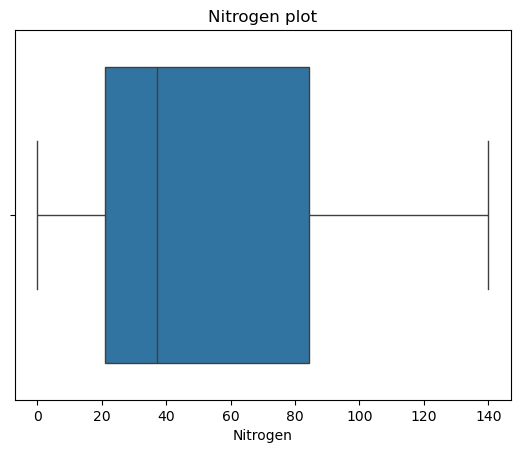

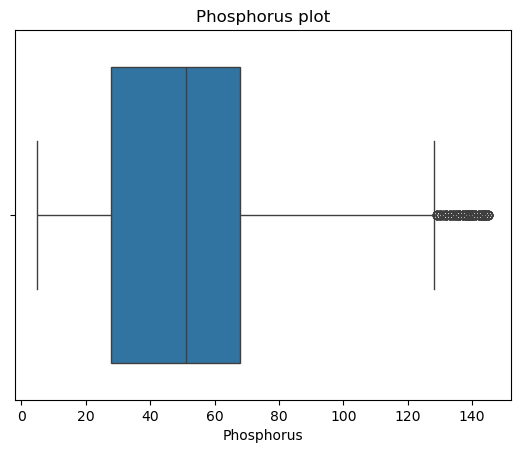

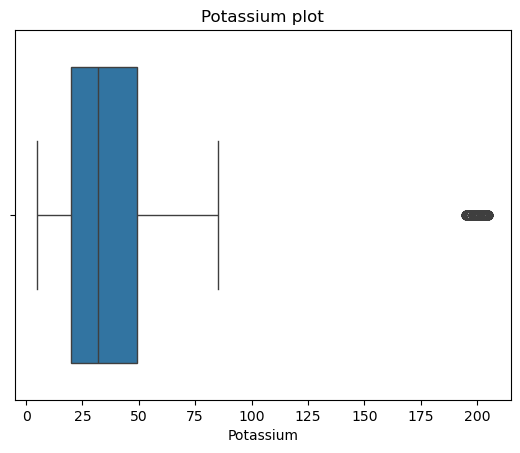

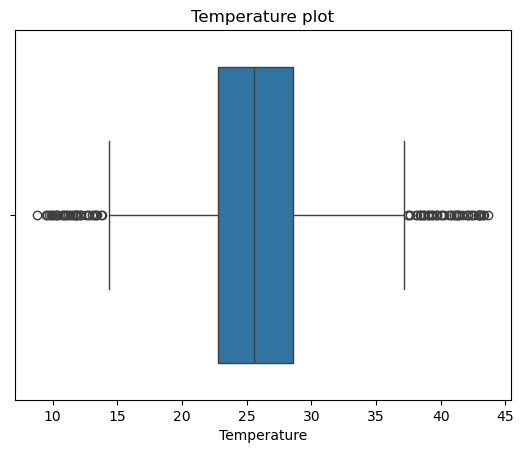

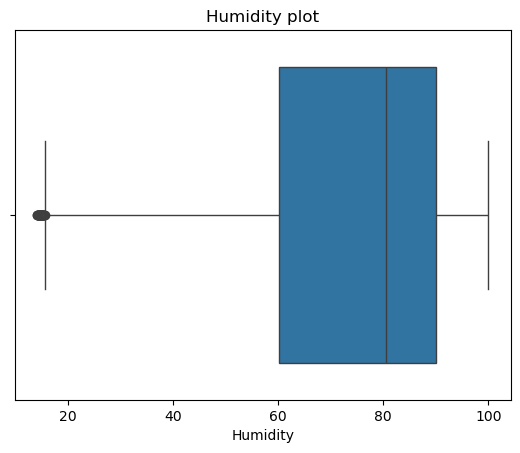

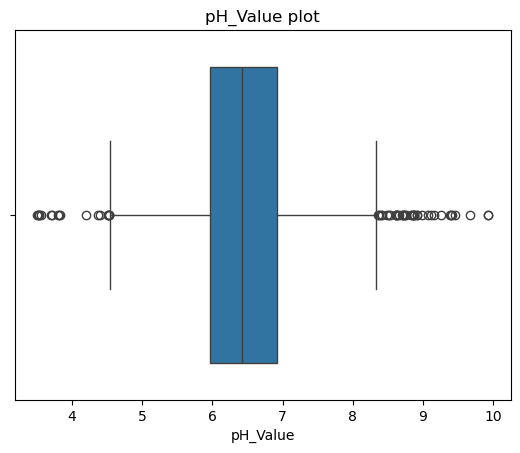

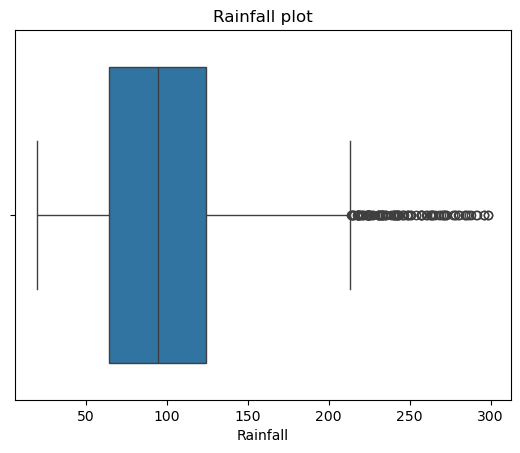

In [7]:
features = df.columns.drop('Crop')

for i in features:
    sns.boxplot(df[i], orient='h')
    plt.title(f'{i} plot')
    plt.show()

In [8]:
from scipy.stats.mstats import winsorize

In [9]:
# Outlier types
mild = ['Phosphorus','Temperature','Humidity','pH_Value','Rainfall']
med = ['Potassium']

for i in features:
    if i in mild:
        df[i] = winsorize(df[i], limits=[0.01,0.01])
    else:
        df[i] = winsorize(df[i], limits=[0.05,0.05])

In [10]:
df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,116,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,116,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


# Data preprocessing

### Normalization 

Normalization means scaling values so they all fall between 0 and 1.  
I used it here because my dataset doesn’t have a wide range, so StandardScaler isn’t really needed — normalization just makes more sense in this case.  

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
mm = MinMaxScaler()

In [13]:
df[features] = mm.fit_transform(df[features])

In [14]:
df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,0.767857,0.262774,0.152174,0.312559,0.816938,0.459600,0.735684,Rice
1,0.723214,0.379562,0.141304,0.343315,0.796348,0.589080,0.832079,Rice
2,0.500000,0.357664,0.157609,0.385923,0.820829,0.783165,0.983696,Rice
3,0.625000,0.211679,0.135870,0.506314,0.794375,0.575119,0.897948,Rice
4,0.660714,0.262774,0.146739,0.286677,0.812071,0.731932,0.978629,Rice
...,...,...,...,...,...,...,...,...
2195,0.919643,0.204380,0.092391,0.516104,0.626220,0.526644,0.633433,Coffee
2196,0.848214,0.065693,0.065217,0.538288,0.506612,0.358926,0.430851,Coffee
2197,1.000000,0.197080,0.081522,0.424849,0.636152,0.425633,0.615343,Coffee
2198,1.000000,0.189781,0.103261,0.498763,0.451450,0.521497,0.427806,Coffee


### Label encoding

In [15]:
# To encode our categorical data - target
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()

In [17]:
df['Crop'] = le.fit_transform(df['Crop'])

In [18]:
df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,0.767857,0.262774,0.152174,0.312559,0.816938,0.459600,0.735684,20
1,0.723214,0.379562,0.141304,0.343315,0.796348,0.589080,0.832079,20
2,0.500000,0.357664,0.157609,0.385923,0.820829,0.783165,0.983696,20
3,0.625000,0.211679,0.135870,0.506314,0.794375,0.575119,0.897948,20
4,0.660714,0.262774,0.146739,0.286677,0.812071,0.731932,0.978629,20
...,...,...,...,...,...,...,...,...
2195,0.919643,0.204380,0.092391,0.516104,0.626220,0.526644,0.633433,5
2196,0.848214,0.065693,0.065217,0.538288,0.506612,0.358926,0.430851,5
2197,1.000000,0.197080,0.081522,0.424849,0.636152,0.425633,0.615343,5
2198,1.000000,0.189781,0.103261,0.498763,0.451450,0.521497,0.427806,5


# Data splitting

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df[features]
y = df['Crop']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [21]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1540, 7) (1540,) (660, 7) (660,)


### Class imbalance 

In [22]:
y.value_counts()

Crop
20    100
11    100
3     100
9     100
18    100
13    100
14    100
2     100
10    100
19    100
1     100
12    100
7     100
21    100
15    100
0     100
16    100
17    100
4     100
6     100
8     100
5     100
Name: count, dtype: int64

# Model building A

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
# The more the depth of the tree, the more prone it is to overfitting 
rf = RandomForestClassifier(n_estimators=70, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,70
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Check list of all hyperparameters RF has
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

# Evaluation A

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [27]:
y_pred = rf.predict(X_test)

In [28]:
acc = rf.score(X_test, y_test)
pre = precision_score(y_test, y_pred, average='macro')
re = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cr = classification_report(y_test, y_pred)

In [29]:
print(f"Accuracy Score       : {acc:.4f}")
print(f"Precision Score      : {pre:.4f}")
print(f"Recall Score         : {re:.4f}")
print(f"F1 Score             : {f1:.4f}")
print("\nClassification Report:\n")
print(cr)

Accuracy Score       : 0.9742
Precision Score      : 0.9754
Recall Score         : 0.9742
F1 Score             : 0.9740

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       0.88      0.97      0.92        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       0.97      1.00      0.98        30
           7       1.00      1.00      1.00        30
           8       0.86      1.00      0.92        30
           9       1.00      1.00      1.00        30
          10       0.93      0.90      0.92        30
          11       0.97      0.97      0.97        30
          12       1.00      1.00      1.00        30
          13       0.89      0.80      0.84        30
          14       1.00      1.00      1.00 